In [1]:
import matplotlib.pyplot as plt
from sklearn import pipeline
from rdkit import Chem
import seaborn as sns
import pandas as pd
import numpy as np
import sklearn
import scipy

In [2]:
def get_high_corr(X):
    corr_matrix = X.corr().abs()

    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    return (
        upper.unstack()
        .dropna()
        .sort_values(ascending=False)
    )

In [3]:
df = pd.read_csv("../data/processed_dataset_wo_metals_w_even_more_qm2.csv")

In [4]:
df.columns

Index(['id', 'atomization_energy', 'homo_lumo_gap', 'ionization_energy',
       'electron_affinity', 'chemical_potential', 'molecular_dipole_norm',
       'molecular_quadrupole_principal_invariant_2',
       'molecular_quadrupole_principal_invariant_3',
       'molecular_polarizability_mean',
       ...
       'fr_sulfone', 'fr_term_acetylene', 'fr_tetrazole', 'fr_thiazole',
       'fr_thiocyan', 'fr_thiophene', 'fr_unbrch_alkane', 'fr_urea',
       'canon_smiles', 'solubility'],
      dtype='str', length=354)

In [5]:
y = df["solubility"]
X = df.drop(["solubility", "smiles", "canon_smiles", "id"], axis=1)

In [6]:
high_corr = get_high_corr(X)

In [7]:
high_corr[high_corr > 0.95].head(50)

fr_amide                              NumAmideBonds                           1.000000
fr_Nhpyrrole                          fr_Ar_NH                                1.000000
solvation_energy_dmso                 solvation_energy_water                  1.000000
min_partial_charge_dmso               min_partial_charge_water                1.000000
std_partial_charge_dmso               std_partial_charge_water                1.000000
max_partial_charge_dmso               max_partial_charge_water                0.999998
MaxEStateIndex                        MaxAbsEStateIndex                       0.999997
ExactMolWt                            MolWt                                   0.999987
solvation_energy_dmso                 solvation_energy_thf                    0.999986
solvation_energy_thf                  solvation_energy_water                  0.999984
min_partial_charge_dmso               min_partial_charge_thf                  0.999957
std_partial_charge_dmso               std_p

There seem to be quite a lot of features that correlate perfectly with each other (Pearson correlation of 1). There also seem to be some features that essentially say the same thing, like MolWt and ExactMolWt. As they serve no purpose besides increasing the amount of dimensions of our data, we can remove them. 

In [19]:
energy_corr = X.corr()["chemical_potential"].sort_values()
energy_corr.abs().sort_values(ascending=False).head(50)

chemical_potential                1.000000
electron_affinity                 0.895428
ionization_energy                 0.889967
std_energy                        0.862175
delta_energy                      0.828806
energy_range                      0.828785
enthalpy_range                    0.796073
std_enthalpy                      0.793584
std_gibbs_free_energy_300K        0.774429
gibbs_free_energy_300K_range      0.758109
solvation_energy_cyclohexane      0.716928
solvation_energy_thf              0.716840
solvation_energy_dmso             0.716648
solvation_energy_water            0.716627
std_heat_capacity_300K            0.611350
max_partial_charge                0.572159
max_partial_charge_cyclohexane    0.552718
ir_norm_intensity_2750_4000       0.551154
heat_capacity_300K_range          0.545402
max_partial_charge_thf            0.537573
fr_COO2                           0.533321
fr_COO                            0.532926
max_partial_charge_dmso           0.532589
max_partial

Index(['SMR_VSA8', 'SlogP_VSA9'], dtype='str')


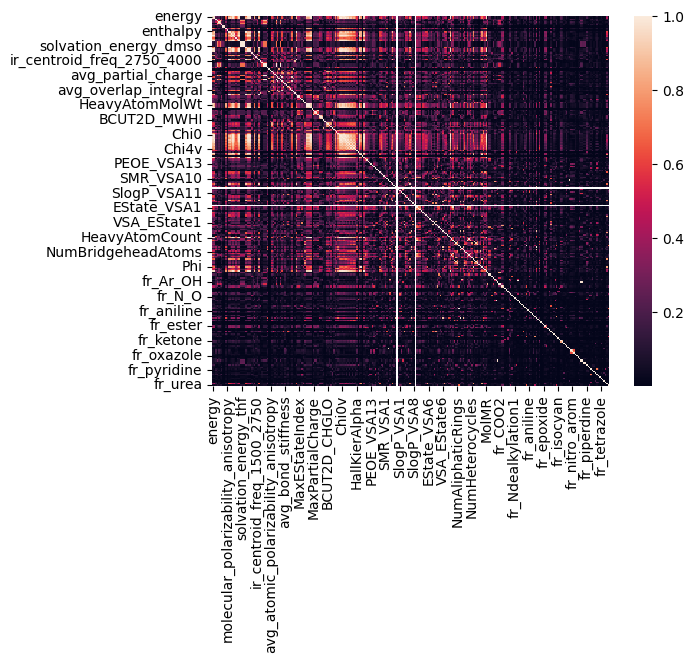

In [53]:
corr = X.corr().abs()

sns.heatmap(corr)
print(X.columns[X.std() == 0])

The Pearson correlation plot reveals there are two features that correlate with 0 other features: `"SMR_VSA8"` and `"SlogP_SVA9"`. This is because these features are constant. They can be removed as they provide zero information to the model.

In [54]:
@np.vectorize
def get_redundant_cols(column):
    return (
        ("solvation_energy" in column and column != "solvation_energy_water") 
        or "avg_partial_charge_" in column 
        or column in ("avg_atomic_fukui_minus", "fr_Nhpyrrole", "NumAmideBonds", "MolWt", "SMR_VSA8", "SlogP_VSA9")
    )

In [65]:
drop_cols = X.columns[get_redundant_cols(X.columns)]
drop_cols, len(drop_cols)

(Index(['solvation_energy_thf', 'solvation_energy_cyclohexane',
        'solvation_energy_dmso', 'avg_partial_charge_cyclohexane',
        'avg_partial_charge_dmso', 'avg_partial_charge_thf',
        'avg_atomic_fukui_minus', 'avg_partial_charge_water', 'MolWt',
        'SMR_VSA8', 'SlogP_VSA9', 'NumAmideBonds', 'fr_Nhpyrrole'],
       dtype='str'),
 13)

In [56]:
new_X = X.drop(drop_cols, axis=1, errors="ignore")

In [57]:
high_corr = get_high_corr(new_X)

high_corr[high_corr > 0.95].head(n=50)

MaxEStateIndex           MaxAbsEStateIndex          0.999997
num_heavy_H_bonds        ir_mode_count_2750_4000    0.999710
fr_benzene               NumAromaticCarbocycles     0.999272
fr_COO2                  fr_COO                     0.999105
HeavyAtomCount           Chi1                       0.998586
NumValenceElectrons      energy                     0.997770
ExactMolWt               HeavyAtomMolWt             0.997020
num_heavy_H_bonds        enthalpy                   0.996626
HeavyAtomCount           Chi0                       0.996527
ir_mode_count_2750_4000  enthalpy                   0.996486
gibbs_free_energy_300K   enthalpy                   0.995471
Chi0                     energy                     0.995071
                         NumValenceElectrons        0.995047
heat_capacity_300K       molecular_volume           0.994381
molecular_sasa           molecular_volume           0.993700
Chi0n                    atomization_energy         0.993381
Kappa1                  

<Axes: >

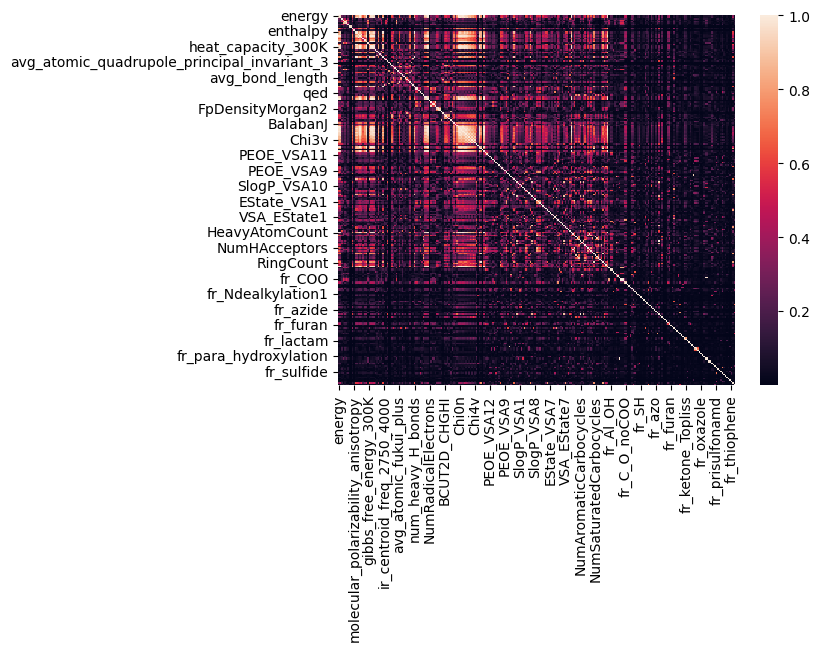

In [58]:
corr = new_X.corr().abs()

sns.heatmap(corr)

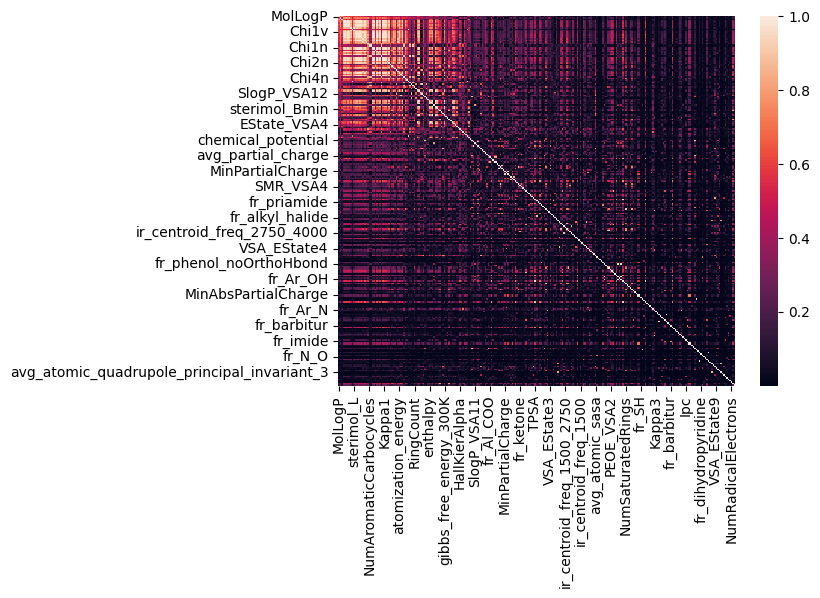

In [62]:
corr_target = new_X.corrwith(y).abs().sort_values(ascending=False)

sorted_features = corr_target.index
corr_sorted = X[sorted_features].corr()

sns.heatmap(corr_sorted.abs())
plt.show()